In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
def compute_spectra(bins, v, ndft):
    sfdr = np.zeros(len(bins))
    hd3 = np.zeros(len(bins))
    spec_dbv_out = np.zeros((len(bins), ndft//2+1))
    for i in bins:
        y = v[i-1, :]
        y = y[:-1]
        relative_error = (y[-1]-y[-1-ndft])/y[-1]
        print(relative_error)
        y = y[-ndft:]
        spec = np.fft.rfft(y)
        spec_dbv = 20*np.log10(np.abs(spec)/(ndft/2))
        spec_dbv_out[i-1, :] = spec_dbv
        sfdr[i-1] = spec_dbv[i] - np.max(np.delete(spec_dbv, [0, i]))
        hd3[i-1] = spec_dbv[i] - spec_dbv[get_third_harmonic_bin(i, ndft)]
    return sfdr, hd3, spec_dbv_out

In [3]:
def get_third_harmonic_bin(i, ndft):
    """
    Finds the 3rd harmonic bin for a real-valued signal.
    i: fundamental bin index
    nfft: total number of FFT points
    """
    # Step 1: Wrap around the sampling frequency
    wrapped_bin = (3 * i) % ndft
    
    # Step 2: Fold back if it's above Nyquist
    if wrapped_bin > ndft // 2:
        harmonic_bin = ndft - wrapped_bin
    else:
        harmonic_bin = wrapped_bin
        
    return int(harmonic_bin)

In [4]:
df = pd.read_csv('./xschem/simulation/tb_track_nmos.txt', sep='\\s+')
df

,time,v(vi1),v(vo1),v(vo2),v(vo3)
0,0.000000e+00,0.300000,0.000871,0.000890,0.002617
1,2.000000e-09,0.323655,0.322903,0.323052,0.323120
2,4.000000e-09,0.346977,0.346177,0.346380,0.346451
3,6.000000e-09,0.369640,0.368798,0.369057,0.369131
4,8.000000e-09,0.391326,0.390450,0.390766,0.390840
...,...,...,...,...,...
1503,1.060000e-07,0.300000,0.283115,0.284872,0.286332
1504,1.080000e-07,0.311848,0.332771,0.327785,0.325943
1505,1.100000e-07,0.276346,0.260726,0.261627,0.262932
1506,1.120000e-07,0.335377,0.357708,0.351117,0.349200


In [5]:
# Parameters
fs = 500e6
ndft = 53
pad = 5
bins = np.arange(1, ndft//2+1)
n = ndft + pad

In [6]:
vi1 = np.reshape(df['v(vi1)'].values, [len(df)//n, n])
vo1 = np.reshape(df['v(vo1)'].values, [len(df)//n, n])
vo2 = np.reshape(df['v(vo2)'].values, [len(df)//n, n])
vo3 = np.reshape(df['v(vo3)'].values, [len(df)//n, n])

hd3_vi1 = compute_spectra(bins, vi1, ndft)[1]
hd3_vo1 = compute_spectra(bins, vo1, ndft)[1]
hd3_vo2 = compute_spectra(bins, vo2, ndft)[1]
hd3_vo3 = compute_spectra(bins, vo3, ndft)[1]

0.0
4.643931695049333e-13
4.2093649296614486e-13
2.0083165331017833e-13
-4.03474290102354e-13
-4.263453532221213e-13
7.119385449752491e-13
0.0
1.388203003654636e-12
-4.558542940659181e-13
0.0
0.0
-1.984223040355874e-12
9.339601749184378e-13
-7.272747639743414e-13
1.0623289874040618e-12
3.953432929145428e-13
1.5448240152295762e-12
1.27768395508335e-12
-6.702553986346791e-13
4.121007675669271e-13
0.0
0.0
0.0
1.2448098318578432e-12
1.1927273546676437e-12
-8.135566527934886e-13
-9.329337009032457e-13
-6.343509194532856e-13
-2.0145494464468582e-13
8.046243475267465e-13
-4.222658310669759e-13
-2.3371505773316716e-13
-2.7375179909881217e-13
3.397472020437854e-13
0.0
6.071054634251066e-13
8.201519224421534e-13
-9.856366351624232e-13
9.467409683070305e-13
1.4965518147152165e-12
1.6510600396707688e-12
8.215533409128251e-13
3.216412302792809e-13
1.0650600838212606e-12
0.0
0.0
-6.088210049167843e-13
4.043126274051193e-13
-4.2328699305507467e-13
-1.4122560944588534e-12
2.7948920318255453e-13
-2.766

In [7]:
# Analytical data 1
vov = 0.4344
vm = 0.20
fs = 500e6
fin = bins*fs/ndft
c = 5e-12
gds = 86e-3
fbw=1/(2*np.pi*c/gds)
hd3_calc1 = -20*np.log10((1/2)*fin/fbw*(vm/vov)**2)
print(fbw/1e6)

2737.4650211805997


In [8]:
# Analytical data 2
vov = 0.734
vm = 0.20
fs = 500e6
fin = bins*fs/ndft
c = 5e-12
cb = 1e-12
cp =  100e-15 + 2e-15
gds = 151e-3
fbw=1/(2*np.pi*c/gds)
hd3_calc2 = -20*np.log10((1/2)*fin/fbw*(vm/vov)**2 *(cp/cb)**2)
print(fbw/1e6)

4806.479281375239


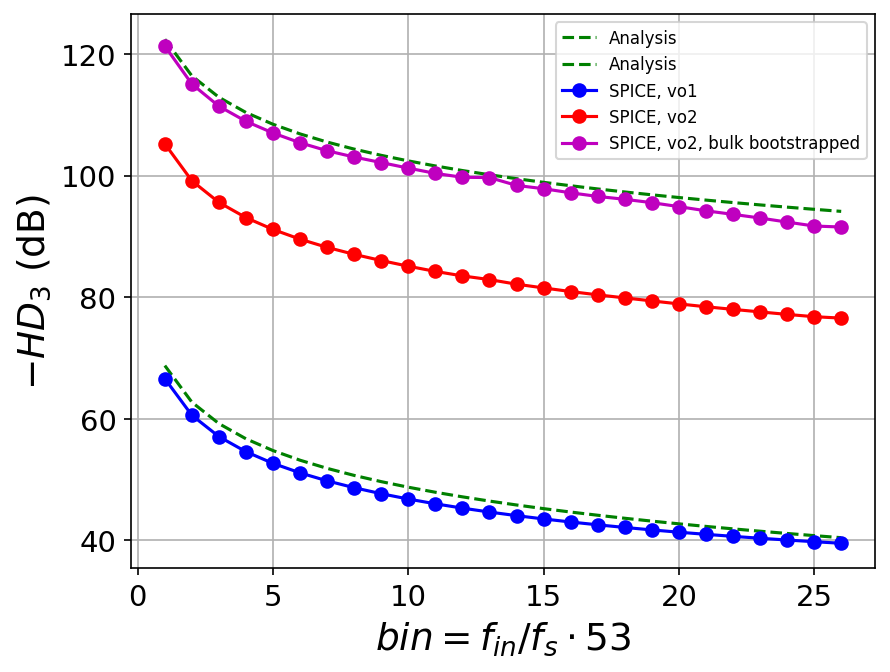

In [9]:
plt.rcParams['figure.dpi'] = 150
plt.plot(bins, hd3_calc1, "g--", label='Analysis')
plt.plot(bins, hd3_calc2, "g--", label='Analysis')

#plt.plot(bins, hd3_vi1, "r-o", label='vi1')
plt.plot(bins, hd3_vo1, "b-o", label='SPICE, vo1')
plt.plot(bins, hd3_vo2, "r-o", label='SPICE, vo2')
plt.plot(bins, hd3_vo3, "m-o", label='SPICE, vo2, bulk bootstrapped')
    
plt.grid()
plt.xlabel("$bin = f_{in}/f_s \\cdot 53$", fontsize=18)
plt.ylabel("$-HD_3$ (dB)", fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
#plt.ylim(25, 72)
plt.grid(True)
plt.legend(fontsize=8)
plt.show()

-2.7667032307511325e-07
-4.131633749326189e-07
-3.848484052952429e-07
-1.7516782300734755e-07
2.1853311422732202e-07
7.8159519297422e-07
1.4846990080264689e-06
2.290044227804554e-06
3.1501485843361384e-06
3.972846946370934e-06
4.496108101837163e-06
4.0390008479920645e-06
1.6639995177621904e-06
-2.0357096495774427e-06
-4.786793787444284e-06
-5.903004017306275e-06
-6.01594377083805e-06
-5.623061554831413e-06
-4.9090134265526315e-06
-3.904265997119982e-06
-2.5904914062754377e-06
-9.523924232207578e-07
9.96118924330711e-07
3.1998152931185344e-06
5.561748433802041e-06
7.953484523564813e-06


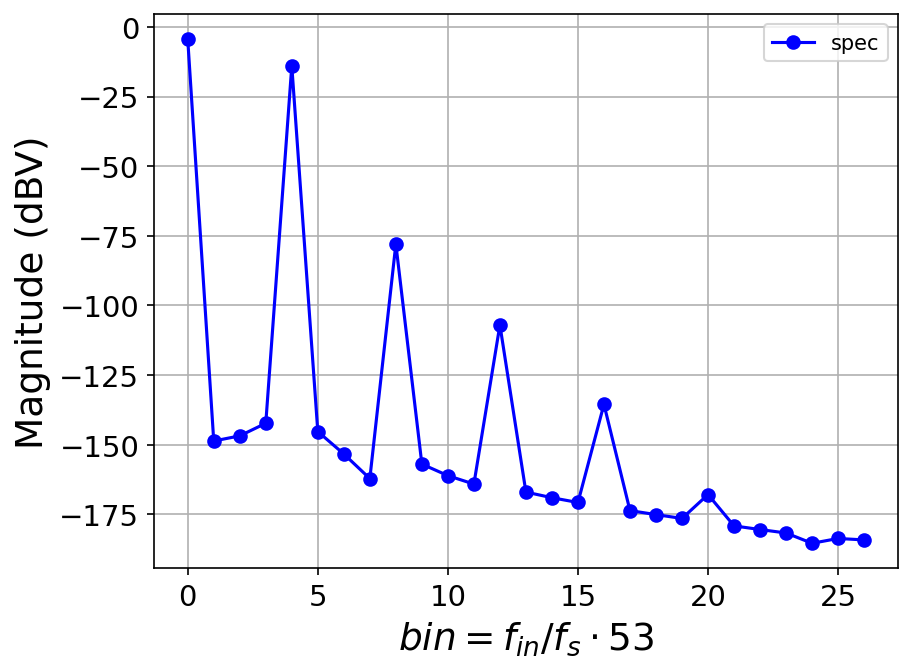

In [10]:
spec_dbv_out = compute_spectra(bins, vo2, ndft)[2]

plt.plot(spec_dbv_out[3, :], "b-o", label='spec')
plt.grid()
plt.xlabel("$bin = f_{in}/f_s \\cdot 53$", fontsize=18)
plt.ylabel("Magnitude (dBV)", fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
#plt.ylim(25, 72)
plt.grid(True)
plt.legend()
plt.show()
